# Install Dependencies and Import

In [1]:
# Install dependencies
!pip install -q --upgrade numerapi numerai-tools optuna xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 23.8 MB/s eta 0:00:00:00:0100:01


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import timedelta
import time

from numerapi import NumerAPI
from numerai_tools.scoring import numerai_corr, correlation_contribution, neutralize

import json
import os
import gc
import shutil
import itertools
from tqdm import tqdm
import random

import xgboost as xgb
import catboost as cb
import lightgbm as lgb
from lightgbm import early_stopping
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import make_scorer
import cloudpickle
import pickle
import optuna
from optuna import Trial
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:.3f}'.format
pd.options.display.max_columns = 500

# Inline plots
%matplotlib inline

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Functions

In [3]:
def per_era_metrics(df, prediction, model_name):
    """Расчёт метрик по эрам: CORR и MMC"""
    per_era_corr = df.groupby("era").apply(lambda x: numerai_corr(x[[prediction]], x["target"]))
    per_era_mmc = df.dropna().groupby("era").apply(lambda x: correlation_contribution(x[[prediction]], x["meta_model"], x["target"]))
    
    def sharpe(series): 
        std = series.std(ddof=0)
        return series.mean() / std if std != 0 else np.nan

    def max_drawdown(series):
        cum = series.cumsum()
        return (cum.expanding().max() - cum).max()
    
    metrics = {
        "model_name": model_name,
        "corr_mean": round(per_era_corr[prediction].mean(), 3),
        "corr_std": round(per_era_corr[prediction].std(ddof=0), 3),
        "corr_sharpe": round(sharpe(per_era_corr[prediction]), 3),
        "corr_max_drawdown": round(max_drawdown(per_era_corr[prediction]), 3),
        "mmc_mean": round(per_era_mmc[prediction].mean(), 3),
        "mmc_std": round(per_era_mmc[prediction].std(ddof=0), 3),
        "mmc_sharpe": round(sharpe(per_era_mmc[prediction]), 3),
        "mmc_max_drawdown": round(max_drawdown(per_era_mmc[prediction]), 3),
    }
    return metrics, per_era_corr, per_era_mmc


In [4]:
def train_and_evaluate(model_type, model_name, params, train, validation, feature_set) -> tuple:
    global results_df

    start_time = time.time()

    # Обучение модели
    model = model_type(**params, random_state=SEED)
    model.fit(train[feature_set], train["target"])
    print("Обучение завершено")

    # Прогноз на Validation
    validation[model_name] = model.predict(validation[feature_set])
    print("Валидация завершена")

    # Расчёт метрик
    formatted_time = str(timedelta(seconds=int(time.time() - start_time)))
    metrics, per_era_corr, per_era_mmc = per_era_metrics(validation, prediction=model_name, model_name=model_name)

    # Добавление метрик в results_df
    new_row = {"model_name": model_name, "time": formatted_time, **metrics}
    results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)

    return validation, results_df, model, per_era_corr, per_era_mmc


In [6]:
def era_wise_cv(train_df, model_name, feature_set, params, model_type, embargo=4, n_splits=5):
    eras = sorted(train_df["era"].unique())
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=embargo)

    results = []
    all_importances = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(eras), 1):
        train_eras = [eras[i] for i in train_idx]
        val_eras = [eras[i] for i in val_idx]

        print(f"\nFold {fold}: Train {train_eras[0]}–{train_eras[-1]}, Val {val_eras[0]}–{val_eras[-1]}")

        train_split = train_df[train_df["era"].isin(train_eras)].copy()
        val_split = train_df[train_df["era"].isin(val_eras)].copy()
        
        X_train, y_train = train_split[feature_set], train_split["target"]
        X_val, y_val = val_split[feature_set], val_split["target"] 


        model = model_type(**params, random_state=SEED)
        model.fit(X_train, y_train)
        val_split["prediction"] = model.predict(X_val)

        per_era_corr = val_split.groupby("era").apply(lambda x: numerai_corr(x[["prediction"]], x["target"]))["prediction"] 
        corr_mean = per_era_corr.mean()
        corr_std = per_era_corr.std(ddof=0)
        corr_sharpe = corr_mean / corr_std if corr_std != 0 else np.nan

        results.append({
            "fold": str(fold),
            "train_eras": f"{train_eras[0]}-{train_eras[-1]}",
            "val_eras": f"{val_eras[0]}-{val_eras[-1]}",
            "corr_sharpe": round(corr_sharpe, 3),
            "corr_mean": round(corr_mean, 3),
            "corr_std": round(corr_std, 3),
        })
        

        importance = pd.DataFrame({
            "feature": feature_set,
            "importance": model.feature_importances_})
        all_importances.append(importance.set_index("feature"))


        del model
        gc.collect()


    # Сборка результатов
    cv_results = pd.DataFrame(results)
    cv_mean = cv_results.mean(numeric_only=True).round(3).to_dict()
    cv_mean["model_name"] = model_name
    cv_results = pd.concat([cv_results, pd.DataFrame([cv_mean])], ignore_index=True)
    

    # Сборка важности признаков
    importance_df = pd.concat(all_importances, axis=1).mean(axis=1).sort_values(ascending=False).reset_index()
    importance_df.columns = ["feature", "importance"]


    return cv_results, cv_mean, importance_df 

In [8]:
def save_experiment(model, model_name, validation_data, results_df):
    """
    Сохраняет модель, validation с предсказаниями и таблицу результатов в файлы.

    Параметры:
        model: обученная модель (например, LGBMRegressor, XGBRegressor)
        validation_data: pd.DataFrame с target и предсказаниями
        results_df: pd.DataFrame с метриками
        prefix: префикс для имён файлов (по умолчанию "experiment")
    """
    # Имена файлов
    model_file = f"/content/drive/MyDrive/Colab Notebooks/{model_name}.pkl"
    validation_file = "/content/drive/MyDrive/Colab Notebooks/val_med_pred.pkl"
    results_file = "/content/drive/MyDrive/Colab Notebooks/results_med.pkl"

    # Сохранение
    with open(model_file, "wb") as f:
        pickle.dump(model, f)
    # print(f"Модель сохранена в {model_file}")

    with open(validation_file, "wb") as f:
        pickle.dump(validation_data, f)
    # print(f"Validation с предсказаниями сохранён в {validation_file}")

    with open(results_file, "wb") as f:
        pickle.dump(results_df, f)
    # print(f"Таблица результатов сохранена в {results_file}")



## Старые функции

In [ ]:
# def per_era_metrics(df, era="era", target="target", prediction="prediction"):

#     per_era_corr = df.groupby(era).apply(lambda x: numerai_corr(x[[prediction]], x[target]))
#     per_era_mmc = df.dropna().groupby(era).apply(lambda x: correlation_contribution(x[[prediction]], x['meta_model'], x[target]))

#     corr_mean = round(per_era_corr[prediction].mean(), 3)
#     corr_std = round(per_era_corr[prediction].std(ddof=0), 3)
#     corr_sharpe = round(corr_mean / corr_std if corr_std != 0 else np.nan, 3)
#     corr_max_drawdown = round(((per_era_corr[prediction].cumsum().expanding().max() - per_era_corr[prediction].cumsum()).max()), 3)

#     mmc_mean = round(per_era_mmc[prediction].mean(), 3)
#     mmc_std = round(per_era_mmc[prediction].std(ddof=0), 3)
#     mmc_sharpe = round(mmc_mean / mmc_std, 3)
#     mmc_max_drawdown = round((per_era_mmc[prediction].cumsum().expanding(min_periods=1).max() - per_era_mmc[prediction].cumsum()).max(), 3)

#     metrics = {
#         "corr_mean": float(corr_mean),
#         "corr_std": corr_std,
#         "corr_sharpe": float(corr_sharpe),
#         "corr_max_drawdown": corr_max_drawdown,
#         "mmc_mean": float(mmc_mean),
#         "mmc_std": mmc_std,
#         "mmc_sharpe": float(mmc_sharpe),
#         "mmc_max_drawdown": mmc_max_drawdown
#     }

#     return metrics, per_era_corr, per_era_mmc

In [ ]:
# def log_result(model_name: str, metrics: dict, params: dict):
#     """
#     Добавляет результат модели в results_df.
#     """
#     global results_df

#     # Извлечение параметров
#     base_params = {
#         "n_estimators": params.get("n_estimators"),
#         "learning_rate": params.get("learning_rate"),
#         "max_depth": params.get("max_depth"),
#         "colsample_bytree": params.get("colsample_bytree") or params.get("subsample") or params.get("bagging_temperature"),
#         "num_leaves": params.get("num_leaves"),
#         "reg_alpha": params.get("reg_alpha", 0.0),
#         "reg_lambda": params.get("reg_lambda", 0.0),
#     }

#     # Новая строка
#     new_row = {
#         "model_name": model_name,
#         **{k: metrics.get(k) for k in [
#             "corr_mean", "corr_std", "corr_sharpe", "corr_max_drawdown",
#             "mmc_mean", "mmc_std", "mmc_sharpe", "mmc_max_drawdown"
#         ]},
#         **base_params
#     }

#     # Добавление
#     results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)


In [ ]:
# def log_result(model_name, metrics, params):
#     base_params = {k: params.get(k) for k in [
#         "n_estimators", "learning_rate", "max_depth",
#         "colsample_bytree", "num_leaves", "reg_alpha", "reg_lambda"
#     ]}
#     row = {"model_name": model_name, **metrics, **base_params}
#     global results_df
#     results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)

In [ ]:
# def per_era_metrics(
#     df: pd.DataFrame,
#     era: str = "era",
#     target: str = "target",
#     prediction: str = "prediction"
# ) -> tuple[dict, pd.Series, pd.Series]:
#     """
#     Рассчитывает корреляцию и MMC по эрам.
#     """
#     # Используем .iloc[0] чтобы получить скаляр из Series
#     per_era_corr = df.groupby(era).apply(
#         lambda group: numerai_corr(group[[prediction]], group[target]).iloc[0]
#     )

#     # Для MMC — аналогично
#     if 'meta_model' not in df.columns:
#         per_era_mmc = pd.Series([np.nan] * len(per_era_corr), index=per_era_corr.index)
#     else:
#         df_clean = df.dropna(subset=[prediction, 'meta_model', target])
#         per_era_mmc = df_clean.groupby(era).apply(
#             lambda group: correlation_contribution(
#                 group[[prediction]], 
#                 group['meta_model'], 
#                 group[target]
#             ).iloc[0]
#         )

#     def calculate_stats(series: pd.Series) -> dict:
#         mean = series.mean()
#         std = series.std(ddof=0)
#         sharpe = mean / std if std != 0 else np.nan  # теперь std — число
#         cum = series.cumsum()
#         max_drawdown = (cum.expanding(min_periods=1).max() - cum).max()
#         return {
#             "mean": round(mean, 4),
#             "std": round(std, 4),
#             "sharpe": round(sharpe, 3) if not np.isnan(sharpe) else np.nan,
#             "max_drawdown": round(max_drawdown, 4)
#         }

#     corr_stats = calculate_stats(per_era_corr)
#     mmc_stats = calculate_stats(per_era_mmc)

#     metrics = {
#         "corr_mean": corr_stats["mean"],
#         "corr_std": corr_stats["std"],
#         "corr_sharpe": corr_stats["sharpe"],
#         "corr_max_drawdown": corr_stats["max_drawdown"],
#         "mmc_mean": mmc_stats["mean"],
#         "mmc_std": mmc_stats["std"],
#         "mmc_sharpe": mmc_stats["sharpe"],
#         "mmc_max_drawdown": mmc_stats["max_drawdown"]
#     }

#     return metrics, per_era_corr, per_era_mmc


# Loading Numerai datasets  

В предыдущем блокноте:
- Почистил `train` от эр с пропусками.
- Применил `validation` эмбарго 4 эры и добавил `numerai_meta_model`.
- Сгруппировал признаки по наборам для `medium`.  
  
Загружаю с Google Disk.

In [7]:
# Загрузка подготовленных датасетов
train = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/train_medium.parquet")
validation = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/validation_medium.parquet")

# Загрузка метаданных
with open('/content/drive/MyDrive/Colab Notebooks/dict_medium_clean.pkl', 'rb') as f:
    dict_medium = pickle.load(f)

# Список признаков
feature_set = list(dict_medium['all'])

# Для теста пока сделаю облегчённый вариант.
# train = train[train["era"].isin(train["era"].unique()[::10])]
# validation = validation[validation["era"].isin(validation["era"].unique()[::10])]
# feature_set = feature_set[:50]

# Краткое описание
print(f"Train: {train.shape}, Eras: {train['era'].min()}-{train['era'].max()}")
print(f"Validation: {validation.shape}, Eras: {validation['era'].min()}-{validation['era'].max()}")
print(f"Features: {len(feature_set)}")

Train: (1865208, 739), Eras: 210-574
Validation: (3777642, 740), Eras: 579-1187
Features: 737


In [ ]:
# Основной датафрейм для результатов
results_df = pd.DataFrame(columns=[
    "model_name", "time",
    "corr_sharpe", "corr_mean", "corr_std", "corr_max_drawdown",
    "mmc_mean", "mmc_std", "mmc_sharpe", "mmc_max_drawdown",
])
results_df 

,model_name,time,corr_sharpe,corr_mean,corr_std,corr_max_drawdown,mmc_mean,mmc_std,mmc_sharpe,mmc_max_drawdown


# Training

Чтобы среда Colab не прерывалась, буду все модели считать отдельно.

## Baseline Models with Large Params

### LGBM Regressor 

In [9]:
model_name = "lgbm"
model_type = lgb.LGBMRegressor

params_lgbm = {
    "n_estimators": 20000,
    "learning_rate": 0.001,
    "max_depth": 6,
    "num_leaves": 64,
    "colsample_bytree": 0.1,
    "verbosity": -1,
    "device_type": "gpu",
}

# Обучение и оценка на Validation
validation, results_df, model, _, _ = train_and_evaluate(
    model_type=model_type, 
    model_name=model_name, 
    params=params_lgbm, 
    train=train,
    validation=validation,
    feature_set=feature_set,
)

# Сохранение модели, результатов и validation с предсказаниями
save_experiment(model=model, model_name=model_name, validation_data=validation, results_df=results_df)
results_df

Обучение завершено
Валидация завершена
Модель сохранена в /content/drive/MyDrive/Colab Notebooks/lgbm.pkl
Validation с предсказаниями сохранён в /content/drive/MyDrive/Colab Notebooks/val_med_pred.pkl
Таблица результатов сохранена в /content/drive/MyDrive/Colab Notebooks/results_med.pkl


,model_name,time,corr_sharpe,corr_mean,corr_std,corr_max_drawdown,mmc_mean,mmc_std,mmc_sharpe,mmc_max_drawdown
0,lgbm,1:24:57,1.448,0.031,0.021,0.072,-0.002,0.010,-0.168,0.190


### XGB Regressor

In [11]:
model_name = "xgb"
model_type = xgb.XGBRegressor

params_xgb = {
    "n_estimators": 20000,
    "learning_rate": 0.001,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.1,
    "tree_method": "hist",
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "verbosity": 0,
}

# Обучение и оценка на Validation
validation, results_df, model, _, _ = train_and_evaluate(
    model_type=model_type, 
    model_name=model_name, 
    params=params_xgb, 
    train=train,
    validation=validation,
    feature_set=feature_set)

# Сохранение модели, результатов и validation с предсказаниями
save_experiment(model=model, model_name=model_name, validation_data=validation, results_df=results_df)
results_df

Обучение завершено
Валидация завершена
Модель сохранена в /content/drive/MyDrive/Colab Notebooks/xgb.pkl
Validation с предсказаниями сохранён в /content/drive/MyDrive/Colab Notebooks/val_med_pred.pkl
Таблица результатов сохранена в /content/drive/MyDrive/Colab Notebooks/results_med.pkl


,model_name,time,corr_sharpe,corr_mean,corr_std,corr_max_drawdown,mmc_mean,mmc_std,mmc_sharpe,mmc_max_drawdown
0,lgbm,1:24:57,1.448,0.031,0.021,0.072,-0.002,0.010,-0.168,0.190
1,xgb,4:17:43,1.457,0.031,0.022,0.078,-0.002,0.011,-0.158,0.205


### CatBoost Regressor

In [15]:
model_name = "catboost"
model_type = cb.CatBoostRegressor

params_cat = {
    "iterations": 20000,
    "learning_rate": 0.001,
    "depth": 6,
    "loss_function": "RMSE",       
    "eval_metric": "RMSE",         
    "task_type": "GPU",
    "verbose": 500,
    "boosting_type": "Plain",       
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "random_strength": 1.0,         
}

# Обучение и оценка на Validation
validation, results_df, model, _, _ = train_and_evaluate(
    model_type=model_type, 
    model_name=model_name, 
    params=params_cat, 
    train=train,
    validation=validation,
    feature_set=feature_set)

# Сохранение модели, результатов и validation с предсказаниями
save_experiment(model=model, model_name=model_name, validation_data=validation, results_df=results_df)
results_df

0:	learn: 0.2231793	total: 31.9ms	remaining: 10m 38s
500:	learn: 0.2231214	total: 16.7s	remaining: 10m 51s
1000:	learn: 0.2230733	total: 33.3s	remaining: 10m 32s
1500:	learn: 0.2230290	total: 49.8s	remaining: 10m 13s
2000:	learn: 0.2229875	total: 1m 6s	remaining: 9m 55s
2500:	learn: 0.2229472	total: 1m 22s	remaining: 9m 38s
3000:	learn: 0.2229082	total: 1m 39s	remaining: 9m 21s
3500:	learn: 0.2228698	total: 1m 55s	remaining: 9m 3s
4000:	learn: 0.2228324	total: 2m 11s	remaining: 8m 46s
4500:	learn: 0.2227956	total: 2m 28s	remaining: 8m 30s
5000:	learn: 0.2227592	total: 2m 44s	remaining: 8m 13s
5500:	learn: 0.2227233	total: 3m 1s	remaining: 7m 57s
6000:	learn: 0.2226881	total: 3m 17s	remaining: 7m 41s
6500:	learn: 0.2226531	total: 3m 34s	remaining: 7m 24s
7000:	learn: 0.2226186	total: 3m 50s	remaining: 7m 8s
7500:	learn: 0.2225843	total: 4m 7s	remaining: 6m 51s
8000:	learn: 0.2225508	total: 4m 23s	remaining: 6m 35s
8500:	learn: 0.2225170	total: 4m 39s	remaining: 6m 18s
9000:	learn: 0.222

,model_name,time,corr_sharpe,corr_mean,corr_std,corr_max_drawdown,mmc_mean,mmc_std,mmc_sharpe,mmc_max_drawdown
0,lgbm,1:24:57,1.448,0.031,0.021,0.072,-0.002,0.010,-0.168,0.190
1,xgb,4:17:43,1.457,0.031,0.022,0.078,-0.002,0.011,-0.158,0.205
2,catboost,0:11:18,1.334,0.029,0.022,0.084,-0.001,0.012,-0.126,0.253


## Feature Neutralization

In [14]:
# Создаём колонку для нейтрализации
validation["meta_model_clean"] = validation["meta_model"].fillna(validation["meta_model"].mean())

# Нейтрализация по meta_model
for m in ["lgbm", "xgb", "catboost"]:
    pred_col = m
    neut_col = m + "_neut"
    
    validation[neut_col] = neutralize(
        validation[[pred_col]],         
        validation[["meta_model_clean"]],   
        proportion=0.5            
    )[pred_col]

    # Расчёт метрик для нейтрализованной версии
    metrics_neut, _, _ = per_era_metrics(
        validation, 
        prediction=neut_col, 
        model_name=neut_col
    )

    new_row = {"model_name": neut_col, **metrics_neut}
    results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
    
results_df

,model_name,time,corr_sharpe,corr_mean,corr_std,corr_max_drawdown,mmc_mean,mmc_std,mmc_sharpe,mmc_max_drawdown
0,lgbm,1:24:57,1.448,0.031,0.021,0.072,-0.002,0.010,-0.168,0.190
1,xgb,4:17:43,1.457,0.031,0.022,0.078,-0.002,0.011,-0.158,0.205
2,catboost,0:11:18,1.334,0.029,0.022,0.084,-0.001,0.012,-0.126,0.253
3,lgbm_neut,NaN,1.406,0.030,0.022,0.095,-0.001,0.012,-0.112,0.206
4,xgb_neut,NaN,1.413,0.031,0.022,0.118,-0.001,0.013,-0.109,0.227
5,catboost_neut,NaN,1.291,0.028,0.022,0.145,-0.001,0.014,-0.081,0.278


**ВЫВОД:** 

`xgb` — слишком медленный для такой небольшой выгоды в corr_sharpe.  
`lgbm` — оптимальный баланс скорости и качества.  
`catboost` — быстр, но слаб по метрикам.  

  
При нейтрализации 0.5 есть улучшение MMC при небольшом падении corr_sharpe.

## Era-Wise CV  

In [ ]:
model_name = "lgbm_cv"
model_type = lgb.LGBMRegressor

params_cv = {
    "n_estimators": 20000,
    "learning_rate": 0.001,
    "max_depth": 6,
    "num_leaves": 64,
    "colsample_bytree": 0.1,
    "verbosity": -1,
    "device_type": "gpu",
}


cv_results, cv_mean, importance_df = era_wise_cv(
    model_name=model_name,
    model_type=model_type,
    train_df=train,
    feature_set=feature_set,
    params=params_cv,
    n_splits=5,
    embargo=4)


results_df = pd.concat([results_df, pd.DataFrame([cv_mean])], ignore_index=True)
cv_results

**Вывод:**  
Модель устойчива по времени — нет переобучения на конкретных эрах, сигнал повторяется и сохраняется при смещении окна.  


In [ ]:
# === Настройка и обучение модели LGBM с ранней остановкой ===

model_name = "lgbm_tuned_early"
model_type = lgb.LGBMRegressor

params_tuned_early = {
    "n_estimators": 20000,
    "learning_rate": 0.001,
    "max_depth": 6,
    "num_leaves": 64,
    "colsample_bytree": 0.1,
    "verbosity": -1,
    "device_type": "gpu",
}


# Разделение train на поднаборы для ранней остановки
train_eras = sorted(train["era"].unique())
cutoff = int(len(train_eras) * 0.9)

train_split = train[train["era"].isin(train_eras[:cutoff])]
val_split = train[train["era"].isin(train_eras[cutoff:])]

X_train, y_train = train_split[feature_set], train_split["target"]
X_val, y_val = val_split[feature_set], val_split["target"]

# === Обучение с ранней остановкой ===
start_time = time.time()

model = model_type(**params_tuned_early)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l2",
    callbacks=[early_stopping(stopping_rounds=300)]
)

best_iter = model.best_iteration_
print(f"\n Лучшее количество итераций: {best_iter}")

# Предсказание на Validation
validation[model_name] = model.predict(validation[feature_set], num_iteration=best_iter)

training_time = str(timedelta(seconds=int(time.time() - start_time)))
print(f"Обучение завершено за {training_time}")

# Расчет метрик
metrics, per_era_corr, per_era_mmc = per_era_metrics(validation, prediction=model_name, model_name=model_name)

new_row = {"model_name": model_name, "time": training_time, **metrics}
results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
results_df

# Experiments

In [ ]:
model_name = "lgbm_tuned"
model_type = lgb.LGBMRegressor


params_tuned = {
    # === Основные параметры ===
    "n_estimators": 10000,              # было 20000 → уменьшаем, чтобы не переобучаться
    "learning_rate": 0.005,             # было 0.001 → чуть выше для быстрой сходимости
    "max_depth": 5,                     # было 6 → уменьшаем сложность
    "num_leaves": 32,                   # было 64 → меньше деревьев = меньше переобучения
    "min_data_in_leaf": 2000,           # новое: минимум объектов в листе (стабилизирует)
    
    # === Регуляризация ===
    "reg_alpha": 1.0,                   # L1 регуляризация (обнуляет слабые веса)
    "reg_lambda": 1.0,                  # L2 регуляризация (сглаживает веса)
    "min_gain_to_split": 0.01,          # не сплитить, если прирост < 0.01
    "max_bin": 63,                      # уменьшает точность, но повышает обобщение
    
    # === Сэмплирование (уменьшает корреляцию с мета-моделью) ===
    "colsample_bytree": 0.2,            # было 0.1 → немного увеличиваем, чтобы не терять сигнал
    "subsample": 0.8,                   # bagging: 80% строк на фолд
    "subsample_freq": 1,                # применять subsample каждый шаг
    
    # === Обучение ===
    "verbosity": -1,
    "device_type": "gpu",
    "random_state": SEED,
}


# === Обучение
start_time = time.time()

model = model_type(**params_tuned)
model.fit(train[feature_set], train["target"])
print(f"Обучение завершено")

# Предсказание на Validation
validation[model_name] = model.predict(validation[feature_set])
training_time = str(timedelta(seconds=int(time.time() - start_time)))
print(f"Обучение завершено за {training_time}")

# Оценка
metrics, per_era_corr, per_era_mmc = per_era_metrics(validation, prediction=model_name, model_name=model_name)

new_row = {"model_name": model_name, "time": training_time, **metrics}
results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
results_df


Обучение завершено
Обучение завершено за 0:20:46


,model_name,time,corr_sharpe,corr_mean,corr_std,corr_max_drawdown,mmc_mean,mmc_std,mmc_sharpe,mmc_max_drawdown
0,lgbm,1:24:57,1.448,0.031,0.021,0.072,-0.002,0.010,-0.168,0.190
1,xgb,4:17:43,1.457,0.031,0.022,0.078,-0.002,0.011,-0.158,0.205
2,catboost,0:11:18,1.334,0.029,0.022,0.084,-0.001,0.012,-0.126,0.253
3,lgbm_neut,NaN,1.406,0.030,0.022,0.095,-0.001,0.012,-0.112,0.206
4,xgb_neut,NaN,1.413,0.031,0.022,0.118,-0.001,0.013,-0.109,0.227
5,catboost_neut,NaN,1.291,0.028,0.022,0.145,-0.001,0.014,-0.081,0.278
6,lgbm_tuned,0:20:46,1.523,0.031,0.021,0.063,-0.001,0.010,-0.058,0.161


In [26]:
# === Настройка и обучение модели LGBM с ранней остановкой ===

model_name = "lgbm_tuned_early"
model_type = lgb.LGBMRegressor

params_tuned_early = {
    # === Основные параметры ===
    "n_estimators": 10000,
    "learning_rate": 0.005,
    "max_depth": 5,
    "num_leaves": 32,
    "min_data_in_leaf": 2000,

    # === Регуляризация ===
    "reg_alpha": 1.0,
    "reg_lambda": 1.0,
    "min_gain_to_split": 0.01,
    "max_bin": 63,

    # === Сэмплирование ===
    "colsample_bytree": 0.2,
    "subsample": 0.8,
    "subsample_freq": 1,

    # === Технические ===
    "verbosity": -1,
    "device_type": "gpu",
    "random_state": SEED,
}

# === Разделение train на поднаборы для ранней остановки ===
train_eras = sorted(train["era"].unique())
cutoff = int(len(train_eras) * 0.9)

train_split = train[train["era"].isin(train_eras[:cutoff])]
val_split = train[train["era"].isin(train_eras[cutoff:])]

X_train, y_train = train_split[feature_set], train_split["target"]
X_val, y_val = val_split[feature_set], val_split["target"]

# === Обучение с ранней остановкой ===
start_time = time.time()

model = model_type(**params_tuned_early)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l2"
    callbacks=[early_stopping(stopping_rounds=150)]
)

best_iter = model.best_iteration_
print(f"\n Лучшее количество итераций: {best_iter}")

# Предсказание на Validation
validation[model_name] = model.predict(validation[feature_set], num_iteration=best_iter)

training_time = str(timedelta(seconds=int(time.time() - start_time)))
print(f"Обучение завершено за {training_time}")

# Расчет метрик
metrics, per_era_corr, per_era_mmc = per_era_metrics(validation, prediction=model_name, model_name=model_name)

new_row = {"model_name": model_name, "time": training_time, **metrics}
results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
results_df

Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[3843]	valid_0's l2: 0.0496564

 Лучшее количество итераций: 3843
Обучение завершено за 0:08:16


,model_name,time,corr_sharpe,corr_mean,corr_std,corr_max_drawdown,mmc_mean,mmc_std,mmc_sharpe,mmc_max_drawdown
0,lgbm,1:24:57,1.448,0.031,0.021,0.072,-0.002,0.010,-0.168,0.190
1,xgb,4:17:43,1.457,0.031,0.022,0.078,-0.002,0.011,-0.158,0.205
2,catboost,0:11:18,1.334,0.029,0.022,0.084,-0.001,0.012,-0.126,0.253
3,lgbm_neut,NaN,1.406,0.030,0.022,0.095,-0.001,0.012,-0.112,0.206
4,xgb_neut,NaN,1.413,0.031,0.022,0.118,-0.001,0.013,-0.109,0.227
5,catboost_neut,NaN,1.291,0.028,0.022,0.145,-0.001,0.014,-0.081,0.278
6,lgbm_tuned,0:20:46,1.523,0.031,0.021,0.063,-0.001,0.010,-0.058,0.161
7,lgbm_tuned_early,0:08:16,1.412,0.029,0.021,0.071,-0.001,0.012,-0.060,0.240


In [27]:
# === Настройка и обучение модели LGBM с ранней остановкой ===

model_name = "lgbm_tuned_early300"
model_type = lgb.LGBMRegressor

params_tuned_early300 = {
    # === Основные параметры ===
    "n_estimators": 10000,
    "learning_rate": 0.005,
    "max_depth": 5,
    "num_leaves": 32,
    "min_data_in_leaf": 2000,

    # === Регуляризация ===
    "reg_alpha": 1.0,
    "reg_lambda": 1.0,
    "min_gain_to_split": 0.01,
    "max_bin": 63,

    # === Сэмплирование ===
    "colsample_bytree": 0.2,
    "subsample": 0.8,
    "subsample_freq": 1,

    # === Технические ===
    "verbosity": -1,
    "device_type": "gpu",
    "random_state": SEED,
}

# === Разделение train на поднаборы для ранней остановки ===
train_eras = sorted(train["era"].unique())
cutoff = int(len(train_eras) * 0.9)

train_split = train[train["era"].isin(train_eras[:cutoff])]
val_split = train[train["era"].isin(train_eras[cutoff:])]

X_train, y_train = train_split[feature_set], train_split["target"]
X_val, y_val = val_split[feature_set], val_split["target"]

# === Обучение с ранней остановкой ===
start_time = time.time()

model = model_type(**params_tuned_early300)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l2",
    callbacks=[early_stopping(stopping_rounds=300)]
)

best_iter = model.best_iteration_
print(f"\n Лучшее количество итераций: {best_iter}")

# Предсказание на Validation
validation[model_name] = model.predict(validation[feature_set], num_iteration=best_iter)

training_time = str(timedelta(seconds=int(time.time() - start_time)))
print(f"Обучение завершено за {training_time}")

# Расчет метрик
metrics, per_era_corr, per_era_mmc = per_era_metrics(validation, prediction=model_name, model_name=model_name)

new_row = {"model_name": model_name, "time": training_time, **metrics}
results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
results_df

Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[3843]	valid_0's l2: 0.0496564

 Лучшее количество итераций: 3843
Обучение завершено за 0:08:23


,model_name,time,corr_sharpe,corr_mean,corr_std,corr_max_drawdown,mmc_mean,mmc_std,mmc_sharpe,mmc_max_drawdown
0,lgbm,1:24:57,1.448,0.031,0.021,0.072,-0.002,0.010,-0.168,0.190
1,xgb,4:17:43,1.457,0.031,0.022,0.078,-0.002,0.011,-0.158,0.205
2,catboost,0:11:18,1.334,0.029,0.022,0.084,-0.001,0.012,-0.126,0.253
3,lgbm_neut,NaN,1.406,0.030,0.022,0.095,-0.001,0.012,-0.112,0.206
4,xgb_neut,NaN,1.413,0.031,0.022,0.118,-0.001,0.013,-0.109,0.227
5,catboost_neut,NaN,1.291,0.028,0.022,0.145,-0.001,0.014,-0.081,0.278
6,lgbm_tuned,0:20:46,1.523,0.031,0.021,0.063,-0.001,0.010,-0.058,0.161
7,lgbm_tuned_early,0:08:16,1.412,0.029,0.021,0.071,-0.001,0.012,-0.060,0.240
8,lgbm_tuned_early300,0:08:23,1.412,0.029,0.021,0.071,-0.001,0.012,-0.060,0.240


In [28]:
# === Настройка и обучение модели LGBM с кастомной метрикой numerai_corr ===

model_name = "lgbm_tuned_numcorr"
model_type = lgb.LGBMRegressor

params_tuned_numcorr = {
    # === Основные параметры ===
    "n_estimators": 10000,
    "learning_rate": 0.005,
    "max_depth": 5,
    "num_leaves": 32,
    "min_data_in_leaf": 2000,

    # === Регуляризация ===
    "reg_alpha": 1.0,
    "reg_lambda": 1.0,
    "min_gain_to_split": 0.01,
    "max_bin": 63,

    # === Сэмплирование ===
    "colsample_bytree": 0.2,
    "subsample": 0.8,
    "subsample_freq": 1,

    # === Технические ===
    "verbosity": -1,
    "device_type": "gpu",
    "random_state": SEED,
}

# === Кастомная метрика numerai_corr (упрощённая, все значения в одной эре) ===
def lgb_numerai_corr_metric(y_true, y_pred):
    df = pd.DataFrame({
        "era": np.zeros_like(y_true),  # все в одной эре
        "prediction": y_pred,
        "target": y_true
    })
    corr = numerai_corr(df, "prediction", "target")
    return "numerai_corr", corr, True  # True → чем больше, тем лучше

# === Подготовка данных ===
X_train, y_train = train[feature_set], train["target"]

# === Обучение модели ===
start_time = time.time()

model = model_type(**params_tuned_numcorr)
model.fit(
    X_train, y_train,
    eval_metric=lgb_numerai_corr_metric  # кастомная метрика numerai_corr
)

training_time = str(timedelta(seconds=int(time.time() - start_time)))
print(f"\n⏱️ Обучение завершено за {training_time}")

# === Предсказание на Validation ===
validation[model_name] = model.predict(validation[feature_set])

# === Расчет метрик ===
metrics, per_era_corr, per_era_mmc = per_era_metrics(
    validation,
    prediction=model_name,
    model_name=model_name
)

# Добавление результатов в results_df
new_row = {"model_name": model_name, "time": training_time, **metrics}
results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)

results_df.tail(3)



⏱️ Обучение завершено за 0:09:07


,model_name,time,corr_sharpe,corr_mean,corr_std,corr_max_drawdown,mmc_mean,mmc_std,mmc_sharpe,mmc_max_drawdown
7,lgbm_tuned_early,0:08:16,1.412,0.029,0.021,0.071,-0.001,0.012,-0.060,0.240
8,lgbm_tuned_early300,0:08:23,1.412,0.029,0.021,0.071,-0.001,0.012,-0.060,0.240
9,lgbm_tuned_numcorr,0:09:07,1.523,0.031,0.021,0.063,-0.001,0.010,-0.058,0.161


## Choosing the Best Model  

**Corr Sharpe — качество сигнала**   
XGBoost показывает лучшую стабильность. Это приоритетная метрика.

**Corr Mean — сила сигнала**  
Все модели примерно равны. Нет явного лидера.  

**Max Drawdown — рискованность**   
CatBoost — самый стабильный по рискам, но его sharpe ниже.  

**MMC (Meta Model Contribution) — вклад модели в MetaModel Numerai**  
Все модели вредят MetaModel. Нужно еще будет замерить после нейтрализации.   

**Время обучения — производительность**  
CatBoost — самый быстрый, но не самый точный.  


### Выбор лучшей модели  


In [29]:
results_df

,model_name,time,corr_sharpe,corr_mean,corr_std,corr_max_drawdown,mmc_mean,mmc_std,mmc_sharpe,mmc_max_drawdown
0,lgbm,1:24:57,1.448,0.031,0.021,0.072,-0.002,0.010,-0.168,0.190
1,xgb,4:17:43,1.457,0.031,0.022,0.078,-0.002,0.011,-0.158,0.205
2,catboost,0:11:18,1.334,0.029,0.022,0.084,-0.001,0.012,-0.126,0.253
3,lgbm_neut,NaN,1.406,0.030,0.022,0.095,-0.001,0.012,-0.112,0.206
4,xgb_neut,NaN,1.413,0.031,0.022,0.118,-0.001,0.013,-0.109,0.227
5,catboost_neut,NaN,1.291,0.028,0.022,0.145,-0.001,0.014,-0.081,0.278
6,lgbm_tuned,0:20:46,1.523,0.031,0.021,0.063,-0.001,0.010,-0.058,0.161
7,lgbm_tuned_early,0:08:16,1.412,0.029,0.021,0.071,-0.001,0.012,-0.060,0.240
8,lgbm_tuned_early300,0:08:23,1.412,0.029,0.021,0.071,-0.001,0.012,-0.060,0.240
9,lgbm_tuned_numcorr,0:09:07,1.523,0.031,0.021,0.063,-0.001,0.010,-0.058,0.161


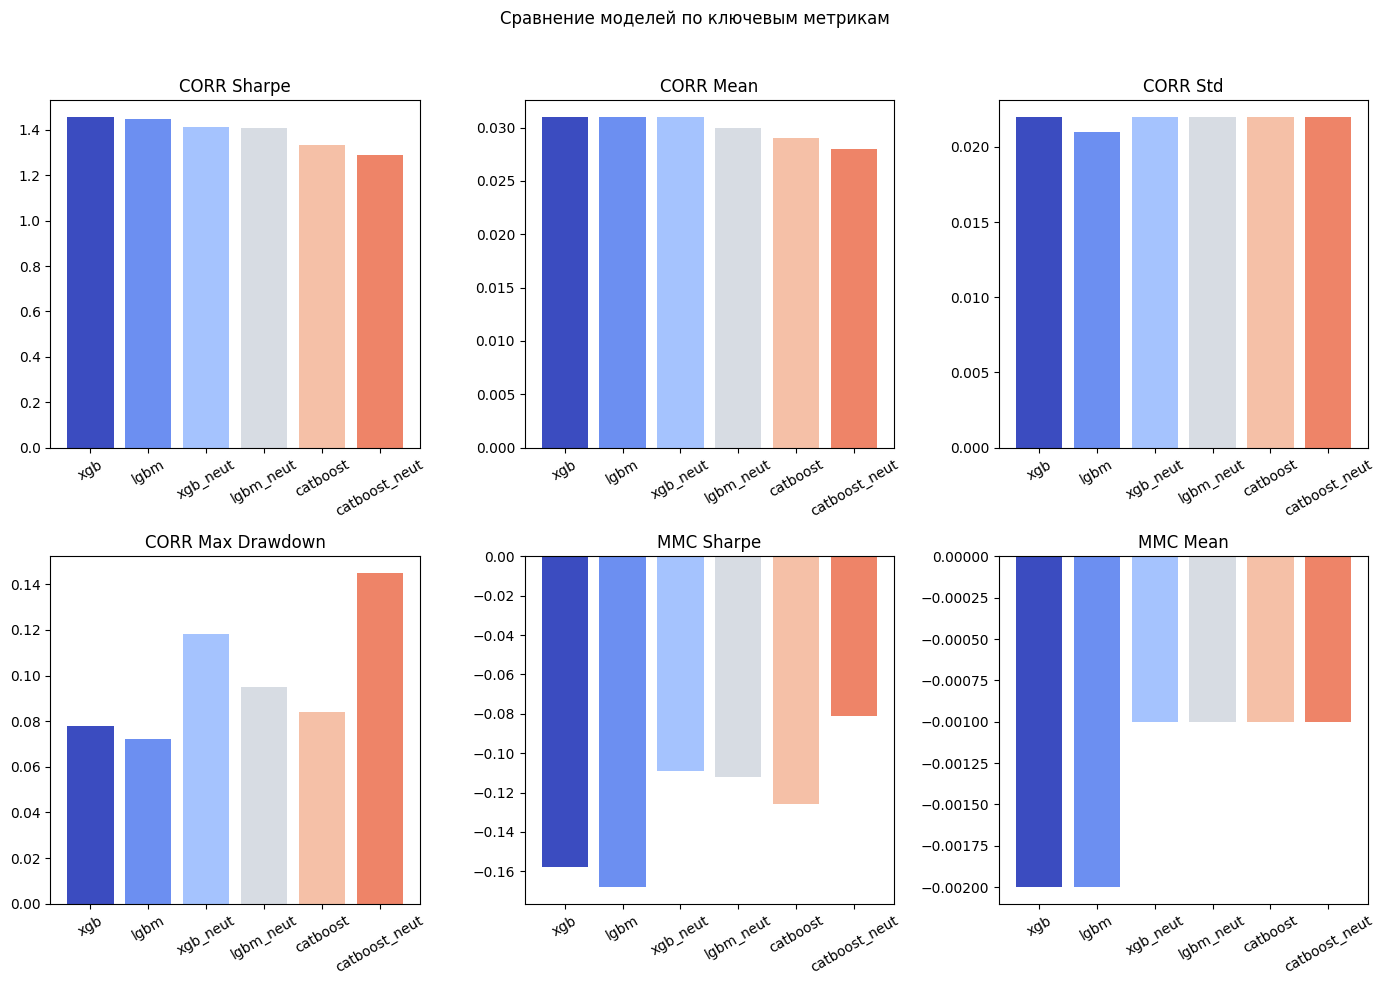

In [16]:
# Список метрик для отображения
metrics_to_plot = [
    ("corr_sharpe", "CORR Sharpe"),
    ("corr_mean", "CORR Mean"),
    ("corr_std", "CORR Std"),
    ("corr_max_drawdown", "CORR Max Drawdown"),
    ("mmc_sharpe", "MMC Sharpe"),
    ("mmc_mean", "MMC Mean"),
    #("time", "Time"),
]

# Сортировка по "corr_sharpe"
results_sorted = results_df.sort_values("corr_sharpe", ascending=False)

# Настройка графиков
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()
plt.suptitle("Сравнение моделей по ключевым метрикам")

# Цветовая схема
colors = plt.cm.coolwarm(np.linspace(0, 0.8, len(results_sorted)))

for i, (metric, title) in enumerate(metrics_to_plot):
    ax = axes[i]
    ax.bar(results_sorted["model_name"], results_sorted[metric], color=colors,)
    ax.set_title(f"{title}")
    ax.tick_params(axis='x', rotation=30)
    
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Optuna

In [31]:
# === Era-Wise CV для Optuna ===
def era_wise_cv_corr(train_df, feature_set, params, model_type, embargo=4, n_splits=5):
    eras = sorted(train_df["era"].unique())
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=embargo)

    corr_sharpes = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(eras), 1):
        train_eras = [eras[i] for i in train_idx]
        val_eras = [eras[i] for i in val_idx]

        train_split = train_df[train_df["era"].isin(train_eras)].copy()
        val_split = train_df[train_df["era"].isin(val_eras)].copy()

        X_train, y_train = train_split[feature_set], train_split["target"]
        X_val, y_val = val_split[feature_set], val_split["target"]

        model = model_type(**params)
        model.fit(X_train, y_train)

        val_split["prediction"] = model.predict(X_val)
        per_era_corr = val_split.groupby("era").apply(
            lambda x: numerai_corr(x[["prediction"]], x["target"])
        )["prediction"]
        corr_mean = per_era_corr.mean()
        corr_std = per_era_corr.std(ddof=0)
        corr_sharpe = corr_mean / corr_std if corr_std != 0 else 0
        corr_sharpes.append(corr_sharpe)

        del model
        gc.collect()

    # Средний corr_sharpe по всем фолдам
    return np.mean(corr_sharpes)

# === Optuna objective ===
def objective(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 5),
        # "num_leaves": trial.suggest_int("num_leaves", 16, 64),
        # "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 500, 5000),
        # "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        # "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
        # "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 0.1),
        # "colsample_bytree": trial.suggest_float("colsample_bytree", 0.1, 0.5),
        # "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        # "subsample_freq": 1,
        "verbosity": -1,
        "device_type": "gpu",
        "random_state": SEED,
    }

    corr_sharpe = era_wise_cv_corr(train, feature_set, params, lgb.LGBMRegressor, embargo=4, n_splits=3)
    return corr_sharpe  # максимизируем corr_sharpe

# === Запуск Optuna ===
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, n_jobs=1)

print("Best corr_sharpe:", study.best_value)
print("Best params:", study.best_params)


In [30]:
model_name = "lgbm_optuna"
model_type = lgb.LGBMRegressor

def objective(trial):
    # Пространство гиперпараметров
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 20),
        # 'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        # 'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        # 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),
        # 'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
        # 'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
        # 'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        # 'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        # 'random_state': SEED,
        'verbosity': -1,
        'device_type': 'gpu'  # если GPU доступен
    }

    # Обучение и оценка с кросс-валидацией
    cv_results, cv_mean, _ = era_wise_cv(
        model_name=model_name,
        model_type=model_type,
        train_df=train,
        feature_set=feature_set,
        n_splits=2,
        params=params,
        embargo=4
    )

    # Целевая метрика — CORR Sharpe
    return cv_mean['corr_sharpe']


In [ ]:
# Создаем study
study = optuna.create_study(
    direction='maximize',  # хотим максимизировать corr_sharpe
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)  # ускоряет подбор
)

# Запускаем оптимизацию
study.optimize(objective, n_trials=50, timeout=600)  # 50 trials или 10 минут


In [ ]:
print("Лучшие параметры:")
print(study.best_params)
print(f"\nЛучшее значение corr_sharpe: {study.best_value:.4f}")

In [ ]:
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

from optuna.visualization import plot_optimization_history, plot_param_importances

fig1 = plot_optimization_history(study)
fig2 = plot_param_importances(study)

iplot(fig1)
iplot(fig2)


## Best Optuna Params

In [ ]:
model_name = "lgbm_optuna"
model_type = lgb.LGBMRegressor

best_params = study.best_params
# best_params['random_state'] = SEED


validation, results_df = train_and_evaluate(
    model_type=model_type, 
    model_name=model_name, 
    params=best_params, 
    train=train,
    validation=validation,
    feature_set=feature_set)

results_df

## Best Optuna CV

In [ ]:
model_name = "lgbm_optuna_cv"
model_type = lgb.LGBMRegressor


cv_results, cv_mean, importance_df = era_wise_cv(
    model_name=model_name,
    model_type=model_type,
    train_df=train,
    feature_set=feature_set,
    n_splits=2,
    params=best_params,
    embargo=4)


results_df = pd.concat([results_df, pd.DataFrame([cv_mean])], ignore_index=True)
cv_results

In [ ]:
results_df

# Feature Neutralization

In [ ]:
proportions = [0.25, 0.5]#, 0.75, 1.0]

for set_name, feat_list in dict_medium.items():
    for proportion in proportions:
        print(f"Neutralizing by {set_name}, proportion={proportion}")

        neutralized = (
            validation.groupby("era", group_keys=True)
            .apply(
                lambda d: neutralize(
                    d[["lgbm_optuna"]],
                    d[list(feat_list)].fillna(0),  # безопасная обработка NaN
                    proportion=proportion
                )
            )
            .reset_index()
            .set_index("id")
        )

        col_name = f"pred_neut_{set_name}_{int(proportion*100)}"
        validation[col_name] = neutralized["lgbm_optuna"]


In [ ]:
for k, v in dict_medium.items():
    print(k, len(v))

In [ ]:
model_name = "lgbm_optuna"
proportions = [0.25, 0.5]
new_dict = {"serenity": list(dict_medium["serenity"]), "charisma": list(dict_medium["charisma"])}
new_dict

In [ ]:
# === НАСТРОЙКИ ===
model_name = "lgbm_optuna"
proportions = [0.25, 0.5]


# === НЕЙТРАЛИЗАЦИЯ И РАСЧЁТ МЕТРИК ===
results = []

for set_name, feat_list in new_dict.items():
    for proportion in proportions:
        print(f"🔹 Neutralizing by {set_name} | proportion={proportion}")

        # per-era нейтрализация
        neutralized = (
            validation.groupby("era", group_keys=True)
            .apply(
                lambda d: neutralize(
                    d[[model_name]],
                    d[list(feat_list)].fillna(0),
                    proportion=proportion
                )
            )
            .reset_index()
            .set_index("id")
        )

        # создаём новую колонку
        col_name = f"pred_neut_{set_name}_{int(proportion*100)}"
        validation[col_name] = neutralized[model_name]

        # считаем метрики per-era
        metrics, _, _ = per_era_metrics(
            validation,
            prediction=col_name,
            model_name=col_name
        )

        # добавляем результаты
        results.append({
            "set": set_name,
            "proportion": proportion,
            "corr_mean": metrics["corr_mean"],
            "corr_sharpe": metrics["corr_sharpe"],
            "corr_max_drawdown": metrics["corr_max_drawdown"],
            "mmc_mean": metrics["mmc_mean"],
            "mmc_sharpe": metrics["mmc_sharpe"],
            "mmc_max_drawdown": metrics["mmc_max_drawdown"],
        })

# === ИТОГОВАЯ ТАБЛИЦА ===
neut_results_df = pd.DataFrame(results)
neut_results_df = neut_results_df.sort_values(by=["corr_sharpe", "mmc_sharpe"], ascending=False)

display(neut_results_df.style.background_gradient(cmap="coolwarm", subset=["corr_sharpe", "mmc_sharpe"]))


In [ ]:
neut_results_df.query("mmc_sharpe > 0.01 and corr_sharpe > 0.21").sort_values("mmc_sharpe", ascending=False)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# === ВИЗУАЛИЗАЦИЯ ===
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# 1️⃣ График зависимости corr_sharpe от proportion
plt.subplot(1, 2, 1)
sns.lineplot(
    data=neut_results_df,
    x="proportion",
    y="corr_sharpe",
    hue="set",
    marker="o"
)
plt.title("CORR Sharpe vs Proportion")
plt.xlabel("Proportion (степень нейтрализации)")
plt.ylabel("CORR Sharpe")
plt.legend(title="Feature Set")
plt.grid(True, linestyle="--", alpha=0.5)

# 2️⃣ График зависимости mmc_sharpe от proportion
plt.subplot(1, 2, 2)
sns.lineplot(
    data=neut_results_df,
    x="proportion",
    y="mmc_sharpe",
    hue="set",
    marker="o"
)
plt.title("MMC Sharpe vs Proportion")
plt.xlabel("Proportion (степень нейтрализации)")
plt.ylabel("MMC Sharpe")
plt.legend(title="Feature Set")
plt.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Анализ нейтрализации по наборам признаков", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()
